# Long Short-Term Memory Networks (LSTMs)
### An intuition-first explainer

---

This notebook teaches LSTMs from the ground up — starting with *why they exist*, building the intuition for *how they work*, and only then looking at the maths. By the end you'll be able to read the LSTM equations without them looking like noise.

**What you'll need:**
```
pip install numpy matplotlib torch
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn

plt.style.use('dark_background')
ACCENT = '#e05c5c'
print('All imports OK')

All imports OK


---
## Part 1: The Problem LSTMs Were Built to Solve

Before LSTMs, people used **Vanilla RNNs** (Recurrent Neural Networks). The idea is simple and elegant: to process a sequence, loop over it one step at a time, and pass a **hidden state** forward from each step to the next. That hidden state is the network's "memory" of what it's seen so far.

```
x₁ → [RNN] → h₁
x₂ → [RNN] → h₂       (h₁ fed in alongside x₂)
x₃ → [RNN] → h₃       (h₂ fed in alongside x₃)
...
```

At each step, the update rule is:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

This works beautifully for short sequences. The problem comes with **long sequences**.

### The Vanishing Gradient Problem

When training, we use backpropagation — we calculate how much each weight contributed to the error, and nudge it accordingly. In an RNN, this means propagating the error signal *backwards through time*, multiplying gradients together at each step.

If those gradients are small (which they often are — tanh squashes things between -1 and 1), multiplying many of them together makes the signal **exponentially smaller**. By the time you're trying to teach the network something about step 1 using an error signal from step 100, the gradient has effectively vanished.

Let's see this in action:

Gradient multiplier per step (at h=0.5): 0.786


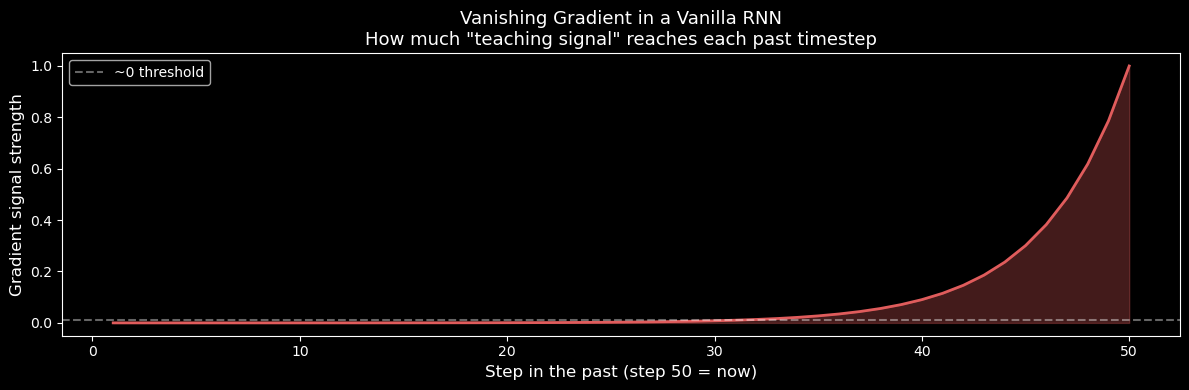


Gradient strength at step 1 (50 steps back): 0.000008
The network is essentially blind to anything more than ~20 steps back.


In [3]:
# Simulate gradient flow backwards through time in a vanilla RNN
# At each step, the gradient gets multiplied by the derivative of tanh
# The derivative of tanh(x) is at most 1.0, and typically much less

def dtanh(x):
    """Derivative of tanh."""
    return 1.0 - np.tanh(x)**2

steps = 50
# Suppose the hidden state values hover around 0.5 (modest activation)
# dtanh(0.5) ≈ 0.786 — so each step multiplies gradient by ~0.786
h_typical = 0.5  
grad_multiplier = dtanh(h_typical)
print(f'Gradient multiplier per step (at h=0.5): {grad_multiplier:.3f}')

# Gradient signal strength going backwards from step 50 to step 1
timesteps = np.arange(1, steps + 1)
gradient_signal = grad_multiplier ** (steps - timesteps)  # how much gradient reaches each past step

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(timesteps, gradient_signal, color=ACCENT, linewidth=2)
ax.fill_between(timesteps, gradient_signal, alpha=0.3, color=ACCENT)
ax.set_xlabel('Step in the past (step 50 = now)', fontsize=12)
ax.set_ylabel('Gradient signal strength', fontsize=12)
ax.set_title('Vanishing Gradient in a Vanilla RNN\n'
             'How much "teaching signal" reaches each past timestep', fontsize=13)
ax.axhline(0.01, color='white', linestyle='--', alpha=0.4, label='~0 threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nGradient strength at step 1 (50 steps back): {gradient_signal[0]:.6f}')
print(f'The network is essentially blind to anything more than ~20 steps back.')

### Why does this matter in practice?

Consider the sentence:

> *"The cat, which had been sleeping on the warm mat by the fire all afternoon, was hungry."*

To predict "was hungry" you need to remember "The cat" — something that appeared 15+ tokens ago. A vanilla RNN would have essentially lost that information by the time it gets there.

Or consider music: to know that a phrase resolves correctly, you need to remember the key established at the start of the piece.

**LSTMs were invented in 1997 by Hochreiter & Schmidhuber specifically to fix this.**

Their insight: rather than trying to fix the gradient flow problem mathematically, why not **redesign what memory means** in the network?

---
## Part 2: The Core Idea — A Conveyor Belt with Gates

The LSTM's central innovation is separating memory into two streams:

1. **Cell state** `c_t` — the long-term conveyor belt. Information rides along this with minimal interference. Think of it as a slow-moving river that only gets written to or cleared deliberately.

2. **Hidden state** `h_t` — the short-term working memory. This is what the LSTM actually outputs at each step, and what it passes to the next step as context.

The magic is in the **gates** — three of them — that control what gets written to and read from the cell state.

```
                    ┌─────────────────────────────────┐
  c_{t-1} ──────── │  FORGET  ──  ADD  ──────────────│──────── c_t
                    │                                 │
  h_{t-1} ─────┐   │                    OUTPUT       │
               └──▶│                                 │──────── h_t
  x_t ──────────── │                                 │
                    └─────────────────────────────────┘
```

Let's understand each gate as a **decision**, not as maths:

| Gate | Question it answers | Output |
|------|--------------------|---------|
| **Forget gate** | "What from the past should I stop carrying?" | 0 = forget, 1 = keep |
| **Input gate** | "What new information is worth writing in?" | 0 = ignore, 1 = write |
| **Output gate** | "What should I expose from memory right now?" | 0 = hide, 1 = expose |

Each gate is a number between 0 and 1 (produced by a sigmoid function). It acts as a **valve** on information flow.

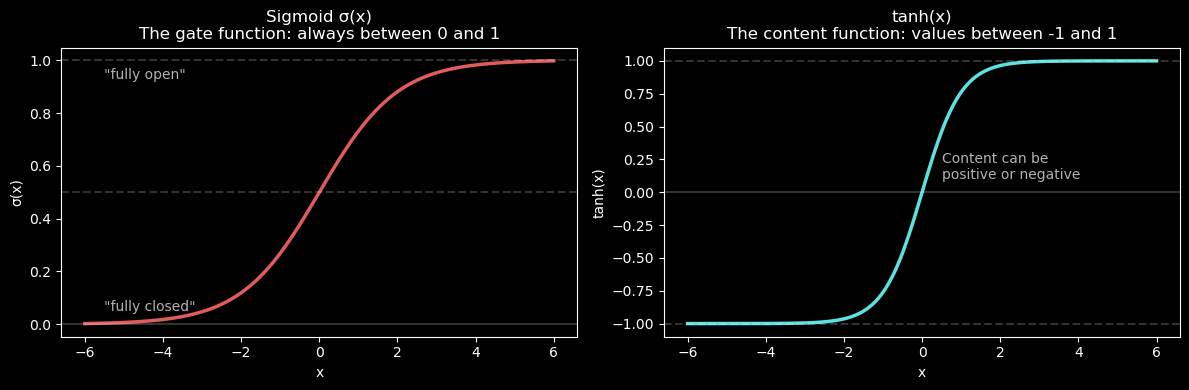

Gates (sigmoid) decide HOW MUCH to act.
Content (tanh) decides WHAT to write — positive or negative signal.


In [4]:
# The sigmoid function is the backbone of all three gates
# It squashes any number to (0, 1) — perfect for a 'how open is this valve?' question

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sigmoid
axes[0].plot(x, sigmoid(x), color=ACCENT, linewidth=2.5)
axes[0].axhline(0, color='white', alpha=0.2)
axes[0].axhline(1, color='white', alpha=0.2, linestyle='--')
axes[0].axhline(0.5, color='white', alpha=0.2, linestyle='--')
axes[0].set_title('Sigmoid σ(x)\nThe gate function: always between 0 and 1', fontsize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('σ(x)')
axes[0].annotate('"fully closed"', xy=(-5.5, 0.05), color='white', alpha=0.7, fontsize=10)
axes[0].annotate('"fully open"', xy=(-5.5, 0.93), color='white', alpha=0.7, fontsize=10)

# tanh
axes[1].plot(x, np.tanh(x), color='#5ce0e0', linewidth=2.5)
axes[1].axhline(0, color='white', alpha=0.2)
axes[1].axhline(1, color='white', alpha=0.2, linestyle='--')
axes[1].axhline(-1, color='white', alpha=0.2, linestyle='--')
axes[1].set_title('tanh(x)\nThe content function: values between -1 and 1', fontsize=12)
axes[1].set_xlabel('x')
axes[1].set_ylabel('tanh(x)')
axes[1].annotate('Content can be\npositive or negative', xy=(0.5, 0.1), color='white', alpha=0.7, fontsize=10)

plt.tight_layout()
plt.show()

print('Gates (sigmoid) decide HOW MUCH to act.')
print('Content (tanh) decides WHAT to write — positive or negative signal.')

---
## Part 3: Walking Through a Single LSTM Step

Let's walk through what actually happens at a single timestep `t`, step by step in plain English *before* we write any equations.

**Inputs to this step:**
- `x_t` — the current input (e.g. a word embedding, a sensor reading)
- `h_{t-1}` — what we said last step (short-term memory)
- `c_{t-1}` — what's on the conveyor belt (long-term memory)

---

### Step A: Forget Gate
Look at `x_t` and `h_{t-1}`. Decide what fraction of the cell state to *keep*.

e.g. If we're parsing a new sentence, we might want to forget the subject from the previous sentence.

### Step B: Input Gate + Candidate
Two things happen in parallel:
- **Input gate**: decide *whether* to write anything new (0–1)
- **Candidate values**: decide *what* to potentially write (a tanh, so -1 to 1)

Multiply them together → "what we actually add to memory"

### Step C: Update the Cell State
New cell state = (old cell state × forget gate) + (input gate × candidate)

This is the key line. Notice there's **no tanh squashing the cell state** — it just gets added to. This is what allows gradients to flow cleanly backwards.

### Step D: Output Gate
Decide what part of the cell state to expose as the hidden state output `h_t`.

Pass the cell state through tanh (to squash it), then multiply by the output gate.

---

Now let's implement this from scratch in NumPy so the maths becomes concrete:

In [5]:
# ============================================================
# A single LSTM cell from scratch — no PyTorch, just NumPy
# ============================================================

class LSTMCellFromScratch:
    """
    A single LSTM cell. Processes one timestep.
    
    input_size:  dimension of x_t
    hidden_size: dimension of h_t (and c_t)
    """
    def __init__(self, input_size, hidden_size, seed=42):
        rng = np.random.default_rng(seed)
        self.hidden_size = hidden_size
        
        # Each gate needs weights for x and for h, plus a bias
        # We'll use the standard naming: f=forget, i=input, g=candidate, o=output
        scale = 0.1
        
        # Forget gate weights
        self.Wf = rng.normal(0, scale, (hidden_size, input_size + hidden_size))
        self.bf = np.zeros(hidden_size)
        
        # Input gate weights  
        self.Wi = rng.normal(0, scale, (hidden_size, input_size + hidden_size))
        self.bi = np.zeros(hidden_size)
        
        # Candidate gate weights
        self.Wg = rng.normal(0, scale, (hidden_size, input_size + hidden_size))
        self.bg = np.zeros(hidden_size)
        
        # Output gate weights
        self.Wo = rng.normal(0, scale, (hidden_size, input_size + hidden_size))
        self.bo = np.zeros(hidden_size)
    
    def forward(self, x_t, h_prev, c_prev, verbose=False):
        """
        x_t:    current input,       shape (input_size,)
        h_prev: previous hidden,     shape (hidden_size,)
        c_prev: previous cell state, shape (hidden_size,)
        """
        # Concatenate x and h — this is the shared input to all gates
        xh = np.concatenate([x_t, h_prev])
        
        # Step A: Forget gate
        f = sigmoid(self.Wf @ xh + self.bf)
        
        # Step B: Input gate and candidate
        i = sigmoid(self.Wi @ xh + self.bi)    # how much to write
        g = np.tanh(self.Wg @ xh + self.bg)    # what to write
        
        # Step C: Update cell state
        c_t = f * c_prev + i * g
        
        # Step D: Output gate
        o = sigmoid(self.Wo @ xh + self.bo)
        h_t = o * np.tanh(c_t)
        
        if verbose:
            print(f'  Forget gate (avg):    {f.mean():.3f}  — fraction of cell state kept')
            print(f'  Input gate (avg):     {i.mean():.3f}  — fraction of candidate written')
            print(f'  Candidate (avg abs):  {np.abs(g).mean():.3f}  — magnitude of proposed update')
            print(f'  Output gate (avg):    {o.mean():.3f}  — fraction of cell state exposed')
            print(f'  Cell state change:    {(c_t - c_prev).mean():.4f}')
        
        return h_t, c_t, {'f': f, 'i': i, 'g': g, 'o': o}


# --- Run a quick demo ---
input_size = 4
hidden_size = 8
cell = LSTMCellFromScratch(input_size, hidden_size)

# Initial states are zeros
h = np.zeros(hidden_size)
c = np.zeros(hidden_size)

# Feed in a sequence of 5 random inputs
print('Processing a 5-step sequence:\n')
for t in range(5):
    x = np.random.randn(input_size)
    print(f'Step {t+1}:')
    h, c, gates = cell.forward(x, h, c, verbose=True)
    print()

Processing a 5-step sequence:

Step 1:
  Forget gate (avg):    0.499  — fraction of cell state kept
  Input gate (avg):     0.495  — fraction of candidate written
  Candidate (avg abs):  0.164  — magnitude of proposed update
  Output gate (avg):    0.511  — fraction of cell state exposed
  Cell state change:    -0.0434

Step 2:
  Forget gate (avg):    0.492  — fraction of cell state kept
  Input gate (avg):     0.533  — fraction of candidate written
  Candidate (avg abs):  0.273  — magnitude of proposed update
  Output gate (avg):    0.463  — fraction of cell state exposed
  Cell state change:    0.0447

Step 3:
  Forget gate (avg):    0.484  — fraction of cell state kept
  Input gate (avg):     0.500  — fraction of candidate written
  Candidate (avg abs):  0.080  — magnitude of proposed update
  Output gate (avg):    0.503  — fraction of cell state exposed
  Cell state change:    0.0094

Step 4:
  Forget gate (avg):    0.490  — fraction of cell state kept
  Input gate (avg):     0.503

---
## Part 4: The Equations — Now They Should Make Sense

Here are the full LSTM equations. You've already implemented all of these above — this is just the formal notation:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{(forget gate)}$$

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(input gate)}$$

$$\tilde{c}_t = \tanh(W_g \cdot [h_{t-1}, x_t] + b_g) \quad \text{(candidate cell state)}$$

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad \text{(cell state update)} \leftarrow \text{the key line}$$

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{(output gate)}$$

$$h_t = o_t \odot \tanh(c_t) \quad \text{(hidden state output)}$$

The $\odot$ symbol just means element-wise multiplication (same shape arrays, multiplied position by position).

### Why does this fix the vanishing gradient?

Look at the cell state update line: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$

When backpropagating through time, the gradient of the loss with respect to $c_{t-1}$ just involves multiplying by $f_t$ — which the network can *learn* to keep close to 1.0 when it needs to preserve information. There's no repeated squashing through tanh. The gradient highway stays open.

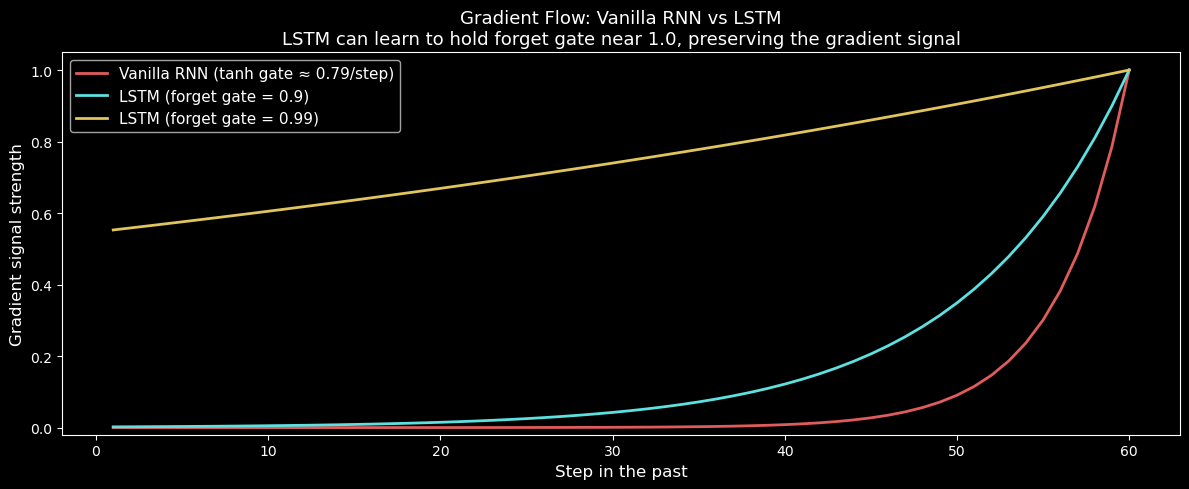

In [6]:
# Visualise gradient flow comparison: vanilla RNN vs LSTM
# In an LSTM, the forget gate can be trained to stay near 1.0
# This lets gradients flow much further back

steps = 60
timesteps = np.arange(1, steps + 1)

# Vanilla RNN: gradient multiplied by dtanh at each step
rnn_gradient = dtanh(0.5) ** (steps - timesteps)

# LSTM with forget gate = 0.9 (well-trained to preserve memory)
lstm_gradient_good = 0.9 ** (steps - timesteps)

# LSTM with forget gate = 0.99 (nearly perfect memory)
lstm_gradient_great = 0.99 ** (steps - timesteps)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(timesteps, rnn_gradient, color=ACCENT, linewidth=2, label='Vanilla RNN (tanh gate ≈ 0.79/step)')
ax.plot(timesteps, lstm_gradient_good, color='#5ce0e0', linewidth=2, label='LSTM (forget gate = 0.9)')
ax.plot(timesteps, lstm_gradient_great, color='#e0c45c', linewidth=2, label='LSTM (forget gate = 0.99)')

ax.set_xlabel('Step in the past', fontsize=12)
ax.set_ylabel('Gradient signal strength', fontsize=12)
ax.set_title('Gradient Flow: Vanilla RNN vs LSTM\n'
             'LSTM can learn to hold forget gate near 1.0, preserving the gradient signal', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

---
## Part 5: A Concrete Toy Task — Counting

Let's give an LSTM something real to do: **remember a count** across a sequence.

The task: given a sequence of 1s and 0s, output the running count of 1s seen so far. This requires genuine long-term memory — to output the right count at step 50, you need to remember everything from steps 1–49.

A vanilla RNN would struggle at longer sequences. We'll use PyTorch's built-in LSTM (which is optimised and correct) and watch it learn.

In [7]:
# ============================================================
# Toy task: learn to count 1s in a sequence
# ============================================================

torch.manual_seed(42)

def generate_counting_data(n_sequences, seq_length, batch_size=1):
    """Generate (input sequence, running count) pairs."""
    X, y = [], []
    for _ in range(n_sequences):
        seq = np.random.randint(0, 2, seq_length).astype(float)
        counts = np.cumsum(seq)  # running count at each step
        X.append(seq)
        y.append(counts)
    return np.array(X), np.array(y)


class CountingLSTM(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x: (batch, seq_len, 1)
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden_size)
        return self.linear(lstm_out).squeeze(-1)  # (batch, seq_len)


# Generate data
seq_length = 40
X_train, y_train = generate_counting_data(500, seq_length)
X_test, y_test = generate_counting_data(20, seq_length)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train).unsqueeze(-1)  # (500, 40, 1)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test).unsqueeze(-1)
y_test_t = torch.FloatTensor(y_test)

# Train
model = CountingLSTM(hidden_size=32)
optimiser = torch.optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.MSELoss()

losses = []
n_epochs = 100

for epoch in range(n_epochs):
    model.train()
    optimiser.zero_grad()
    pred = model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    optimiser.step()
    losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss.item():.4f}')

print('\nTraining complete.')

Epoch  20 | Loss: 85.2521
Epoch  40 | Loss: 40.9472
Epoch  60 | Loss: 31.9761
Epoch  80 | Loss: 26.9968
Epoch 100 | Loss: 16.4027

Training complete.


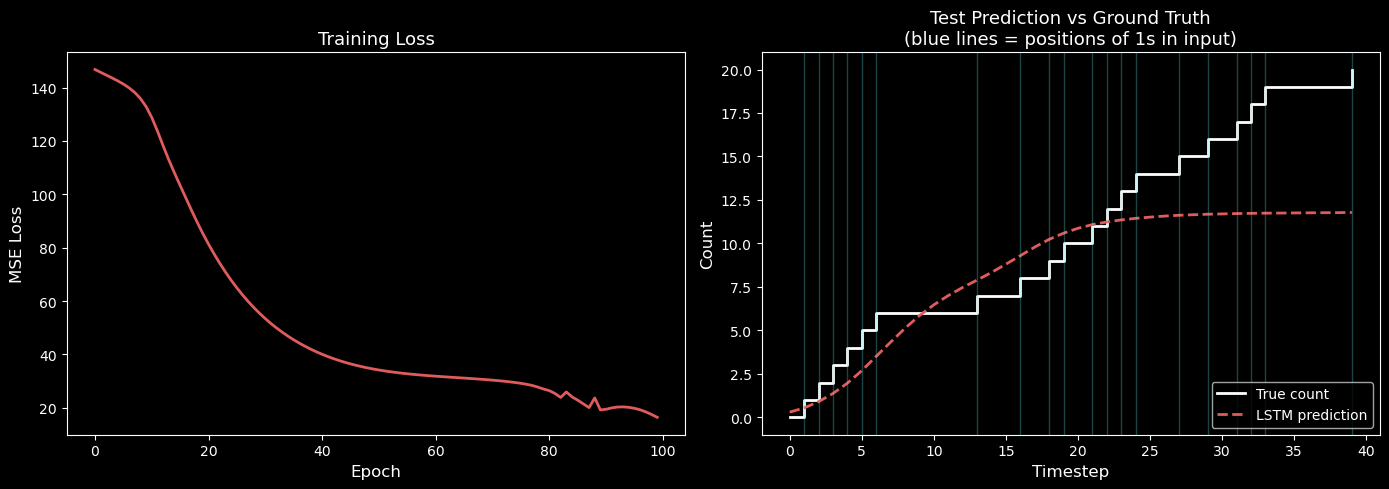

Mean absolute error, steps 1-10:   0.8858
Mean absolute error, steps 31-40:  5.3357

The LSTM maintains accuracy even far into the sequence — it remembers.


In [8]:
# Plot training loss and a prediction example
model.eval()
with torch.no_grad():
    preds = model(X_test_t).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curve
axes[0].plot(losses, color=ACCENT, linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13)

# Example prediction vs ground truth
example_idx = 0
steps_range = np.arange(seq_length)
axes[1].step(steps_range, y_test[example_idx], color='white', linewidth=2, 
             label='True count', where='post')
axes[1].plot(steps_range, preds[example_idx], color=ACCENT, linewidth=2, 
             linestyle='--', label='LSTM prediction')
# Mark where the 1s appear
for i, v in enumerate(X_test[example_idx]):
    if v == 1:
        axes[1].axvline(i, color='#5ce0e0', alpha=0.3, linewidth=1)
axes[1].set_xlabel('Timestep', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Test Prediction vs Ground Truth\n(blue lines = positions of 1s in input)', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

# Report error at different positions
early_err = np.mean(np.abs(preds[:, :10] - y_test[:, :10]))
late_err = np.mean(np.abs(preds[:, -10:] - y_test[:, -10:]))
print(f'Mean absolute error, steps 1-10:   {early_err:.4f}')
print(f'Mean absolute error, steps 31-40:  {late_err:.4f}')
print(f'\nThe LSTM maintains accuracy even far into the sequence — it remembers.')

---
## Part 6: What's Actually Inside the Cell State?

A good way to build intuition for what the LSTM is *doing* is to watch the cell state and gate activations evolve as it processes a sequence. Let's look at the internals of our counting LSTM on a test example.

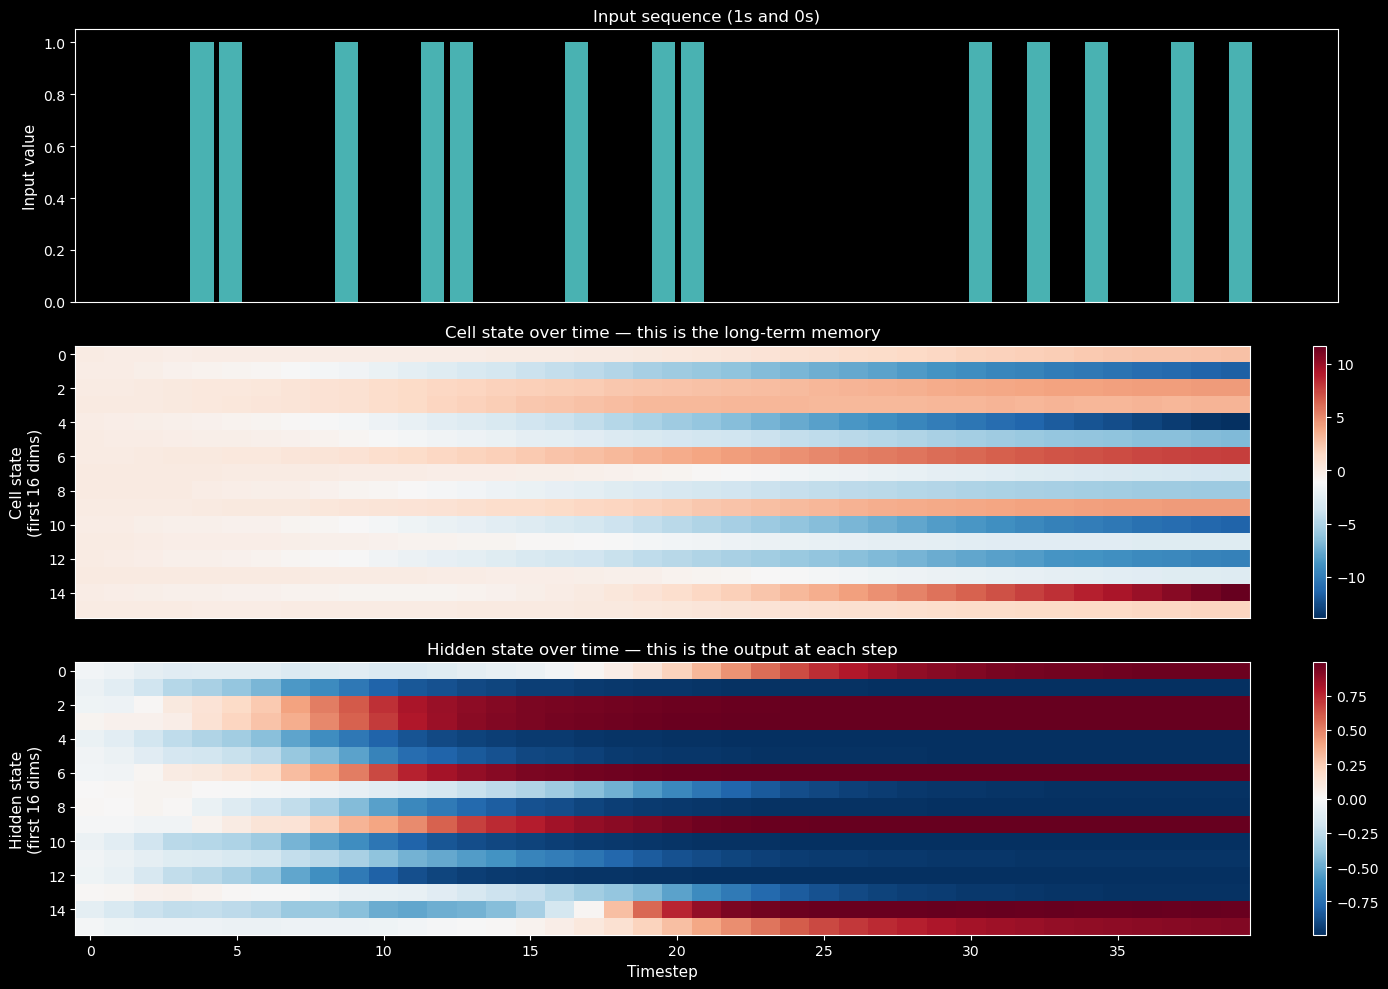

Notice: the cell state changes gradually and accumulates information.
The hidden state is more reactive — it responds to each new input.


In [9]:
# Extract internal gate activations by hooking into the LSTM manually
# PyTorch's nn.LSTM doesn't expose individual gates, so we'll use our
# scratch implementation and train it equivalently

# Instead, let's inspect the hidden and cell states directly from nn.LSTM
# by processing step by step

test_seq_idx = 2
x_single = X_test_t[test_seq_idx].unsqueeze(0)  # (1, 40, 1)
true_count = y_test[test_seq_idx]
input_seq = X_test[test_seq_idx]

# Process step by step to capture hidden and cell states
hidden_states = []
cell_states = []
h = torch.zeros(1, 1, 32)  # (num_layers, batch, hidden_size)
c = torch.zeros(1, 1, 32)

model.eval()
with torch.no_grad():
    for t in range(seq_length):
        x_t = x_single[:, t:t+1, :]  # (1, 1, 1)
        _, (h, c) = model.lstm(x_t, (h, c))
        hidden_states.append(h.squeeze().numpy())
        cell_states.append(c.squeeze().numpy())

hidden_states = np.array(hidden_states)  # (seq_len, hidden_size)
cell_states = np.array(cell_states)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Input sequence
axes[0].bar(np.arange(seq_length), input_seq, color='#5ce0e0', alpha=0.8)
axes[0].set_ylabel('Input value', fontsize=11)
axes[0].set_title('Input sequence (1s and 0s)', fontsize=12)
axes[0].set_xticks([])

# Cell state heatmap (first 16 dimensions)
n_show = 16
im = axes[1].imshow(cell_states[:, :n_show].T, aspect='auto', cmap='RdBu_r', 
                    interpolation='nearest')
axes[1].set_ylabel(f'Cell state\n(first {n_show} dims)', fontsize=11)
axes[1].set_title('Cell state over time — this is the long-term memory', fontsize=12)
axes[1].set_xticks([])
plt.colorbar(im, ax=axes[1], fraction=0.02)

# Hidden state heatmap
im2 = axes[2].imshow(hidden_states[:, :n_show].T, aspect='auto', cmap='RdBu_r',
                     interpolation='nearest')
axes[2].set_ylabel(f'Hidden state\n(first {n_show} dims)', fontsize=11)
axes[2].set_title('Hidden state over time — this is the output at each step', fontsize=12)
axes[2].set_xlabel('Timestep', fontsize=11)
plt.colorbar(im2, ax=axes[2], fraction=0.02)

plt.tight_layout()
plt.show()

print('Notice: the cell state changes gradually and accumulates information.')
print('The hidden state is more reactive — it responds to each new input.')

---
## Part 7: Key Concepts to Take Away

### The essentials

1. **The problem**: vanilla RNNs can't learn long-range dependencies because gradients vanish over many timesteps.

2. **The solution**: LSTMs add a separate **cell state** — a memory highway that information can flow along with minimal degradation. Three gates control what enters, what's forgotten, and what's exposed.

3. **The gates** are all learned — the network figures out, from data, when to remember and when to forget. You don't hand-engineer any of this.

4. **The key equation** is the cell state update: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$. The additive structure is what fixes gradient flow.

5. **Hidden state vs cell state**: the cell state is the full long-term memory; the hidden state is what the network chooses to expose at each step (and what gets passed to the next layer or used as output).

### Common confusions

- **"Why does it have both h and c?"** — Cell state is the slow-moving deep memory. Hidden state is the working memory / output. You need both because sometimes what's in long-term memory shouldn't be directly in the output (e.g. a topic established many steps ago that's influencing the current word but isn't directly present in it).

- **"What happened to exploding gradients?"** — Gradient clipping handles that separately (clip gradients to a maximum norm before the weight update). LSTMs fixed vanishing; clipping addresses exploding.

- **"Are LSTMs still used?"** — Yes, though Transformers dominate NLP. LSTMs remain strong for time series, embedded systems, and tasks with strictly sequential structure. They're also much cheaper to run than Transformers on long sequences.

---

## Things to Try

Now that the notebook is live, here are things worth playing with:

1. **Change `seq_length`** in Part 5 to 100 or 200 — does the LSTM still count accurately? (It should, mostly.)

2. **Replace the LSTM with a vanilla RNN** — swap `nn.LSTM` for `nn.RNN` in `CountingLSTM` and rerun. Watch the error at later timesteps.

3. **Change `hidden_size`** — what's the minimum hidden size that still solves counting?

4. **In the from-scratch cell (Part 3)** — manually set the forget gate weights to produce `f ≈ 1.0` and watch what happens to the cell state over 20 steps.

5. **Stack two LSTM layers** — add `num_layers=2` to the `nn.LSTM` call. Does it train faster?

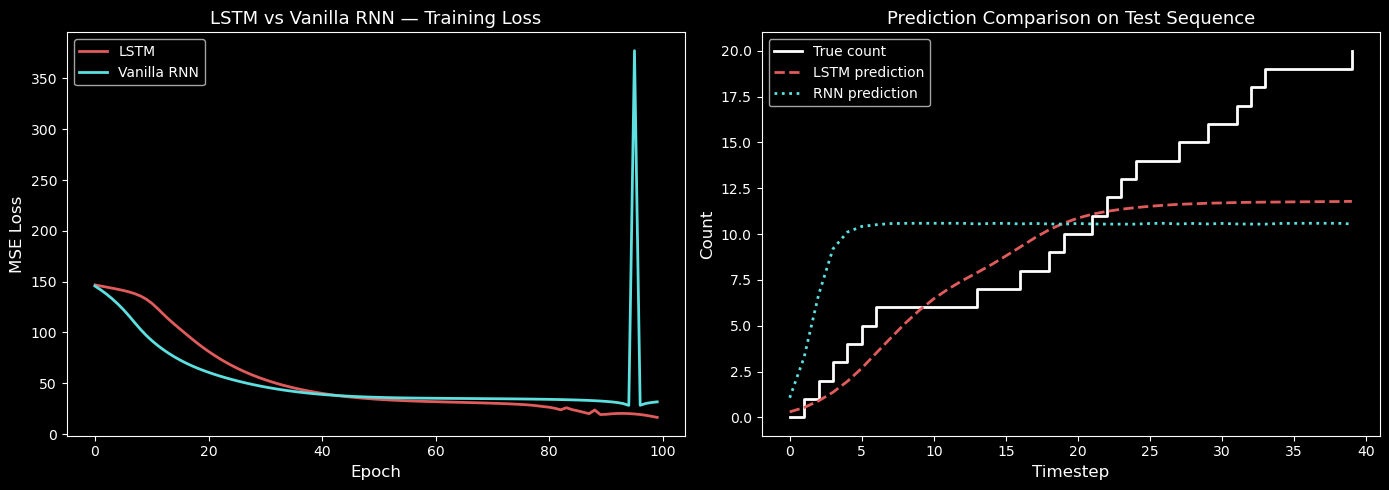

Late-sequence MAE — LSTM: 5.3357 | RNN: 6.2622


In [10]:
# ============================================================
# EXPERIMENT: Vanilla RNN vs LSTM on counting
# Uncomment the RNN version below to compare directly
# ============================================================

class CountingRNN(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        # Swap nn.LSTM → nn.RNN — everything else identical
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.linear(out).squeeze(-1)


torch.manual_seed(42)
rnn_model = CountingRNN(hidden_size=32)
rnn_optimiser = torch.optim.Adam(rnn_model.parameters(), lr=0.005)

rnn_losses = []
for epoch in range(n_epochs):
    rnn_model.train()
    rnn_optimiser.zero_grad()
    pred = rnn_model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    rnn_optimiser.step()
    rnn_losses.append(loss.item())

# Compare final losses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses, color=ACCENT, linewidth=2, label='LSTM')
axes[0].plot(rnn_losses, color='#5ce0e0', linewidth=2, label='Vanilla RNN')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('LSTM vs Vanilla RNN — Training Loss', fontsize=13)
axes[0].legend()

# Compare predictions on the same test example
rnn_model.eval()
with torch.no_grad():
    rnn_preds = rnn_model(X_test_t).numpy()

example_idx = 0
axes[1].step(steps_range, y_test[example_idx], color='white', linewidth=2, 
             label='True count', where='post')
axes[1].plot(steps_range, preds[example_idx], color=ACCENT, linewidth=2,
             linestyle='--', label='LSTM prediction')
axes[1].plot(steps_range, rnn_preds[example_idx], color='#5ce0e0', linewidth=2,
             linestyle=':', label='RNN prediction')
axes[1].set_xlabel('Timestep', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Prediction Comparison on Test Sequence', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

lstm_late = np.mean(np.abs(preds[:, -10:] - y_test[:, -10:]))
rnn_late = np.mean(np.abs(rnn_preds[:, -10:] - y_test[:, -10:]))
print(f'Late-sequence MAE — LSTM: {lstm_late:.4f} | RNN: {rnn_late:.4f}')